## Notebook 06 — Robustness Testing
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** Robustness evaluation of RF and MLP under four image perturbations at five severity levels each


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import pickle
from PIL import Image
from scipy.ndimage import gaussian_filter
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import sys
sys.path.insert(0, os.path.abspath('..'))

In [2]:
CLASSES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
DATASET_PATH = os.path.join('..', 'datasets', 'dataset-resized')
RESULTS_PATH = os.path.join('..', 'results')
FIGURES_PATH = os.path.join('..', 'results', 'figures')
IMAGE_SIZE = (224, 224)
HISTOGRAM_BINS = 32

In [3]:
with open(os.path.join(RESULTS_PATH, 'rf_final_model.pkl'), 'rb') as f:
    rf_model = pickle.load(f)

with open(os.path.join(RESULTS_PATH, 'mlp_final_model.pkl'), 'rb') as f:
    mlp_model = pickle.load(f)

with open(os.path.join(RESULTS_PATH, 'mlp_scaler.pkl'), 'rb') as f:
    mlp_scaler = pickle.load(f)

print("Models loaded successfully")
print(f"RF:  {rf_model}")
print(f"MLP: {mlp_model}")

Models loaded successfully
RF:  RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
MLP: MLPClassifier(alpha=0.01, hidden_layer_sizes=(200,), max_iter=1000,
              random_state=42)


In [4]:
# Feature extraction pipeline (identical to preprocessing notebook) and a sorted dataset loader that optionally applies an image perturbation before computing features

from src.features import extract_features_from_image as extract_features
from src.features import load_dataset


def load_dataset_sorted(perturb_fn=None):
    """
    Load all images in sorted order, optionally applying a perturbation.
    Returns feature matrix and label array.
    """
    return load_dataset(DATASET_PATH, perturb_fn=perturb_fn, classes=CLASSES)


print("Feature extraction functions defined")


Feature extraction functions defined


In [5]:
# Loads the full clean dataset, recreates the standard test split, and verifies that both models reproduce their original test accuracies before perturbation testing begins

print("Loading clean dataset with sorted file order...")
print("(This will take a minute — extracting features from 2527 images)")

clean_features, clean_labels = load_dataset_sorted(perturb_fn=None)

print(f"\nClean feature matrix shape: {clean_features.shape}")
print(f"Clean labels shape: {clean_labels.shape}")

from sklearn.model_selection import train_test_split

_, X_test_clean, _, y_test_clean = train_test_split(
    clean_features, clean_labels,
    test_size=0.15,
    random_state=42,
    stratify=clean_labels
)

X_test_clean_scaled = mlp_scaler.transform(X_test_clean)

rf_clean_acc = rf_model.score(X_test_clean, y_test_clean)
mlp_clean_acc = mlp_model.score(X_test_clean_scaled, y_test_clean)

print(f"\nClean baseline verification:")
print(f"  RF  accuracy: {rf_clean_acc:.4f} (expected ~0.7895)")
print(f"  MLP accuracy: {mlp_clean_acc:.4f} (expected ~0.8053)")
print(f"\nPipeline verified: {abs(rf_clean_acc - 0.7895) < 0.03 and abs(mlp_clean_acc - 0.8053) < 0.03}")

Loading clean dataset with sorted file order...
(This will take a minute — extracting features from 2527 images)



Clean feature matrix shape: (2527, 122)
Clean labels shape: (2527,)

Clean baseline verification:
  RF  accuracy: 0.7895 (expected ~0.7895)
  MLP accuracy: 0.8053 (expected ~0.8053)

Pipeline verified: True


In [6]:
# Four perturbation functions modelling conveyor-belt failure modes — motion blur, Gaussian noise, brightness shift, and JPEG compression — each parameterised by five severity levels

from src.perturbations import (
    apply_motion_blur,
    apply_gaussian_noise,
    apply_brightness,
    apply_jpeg_compression,
    make_perturbation,
    PERTURBATIONS,
    SEVERITIES,
)

print("Perturbation functions defined:")
for name in PERTURBATIONS:
    print(f"  {name}")


Perturbation functions defined:
  motion_blur
  gaussian_noise
  brightness
  jpeg_compression


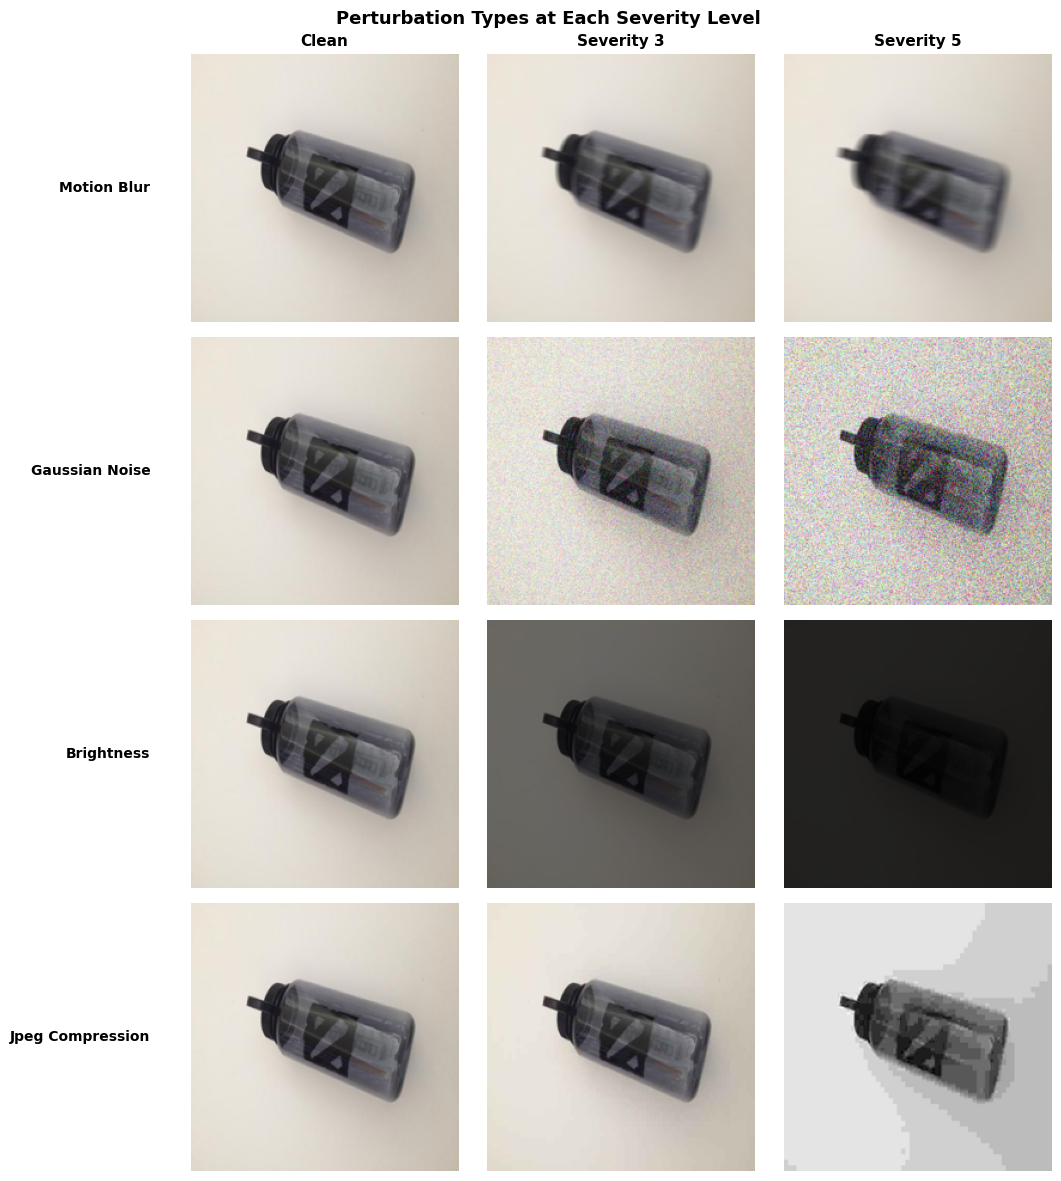

Perturbation visualisation saved.


In [7]:
# Renders a sample image at representative severity levels for each perturbation type as a visual reference

sample_path = os.path.join(DATASET_PATH, 'plastic', sorted(os.listdir(os.path.join(DATASET_PATH, 'plastic')))[0])
sample_image = Image.open(sample_path).convert('RGB')

DISPLAY_COLS = [0, 3, 5]  # clean (0 sentinel), severity 3, severity 5
COL_LABELS   = ['Clean', 'Severity 3', 'Severity 5']

fig, axes = plt.subplots(4, 3, figsize=(11, 12))
perturbation_names = list(PERTURBATIONS.keys())
perturbation_fns   = list(PERTURBATIONS.values())

for row, (name, fn) in enumerate(zip(perturbation_names, perturbation_fns)):
    for col_idx, severity in enumerate(DISPLAY_COLS):
        ax = axes[row, col_idx]
        if severity == 0:
            img = sample_image.resize(IMAGE_SIZE)
        else:
            img = make_perturbation(name, severity)(sample_image).resize(IMAGE_SIZE)
        ax.imshow(img)
        ax.axis('off')
        if row == 0:
            ax.set_title(COL_LABELS[col_idx], fontsize=11, fontweight='bold', pad=6)
    axes[row, 0].text(-0.15, 0.5, name.replace('_', ' ').title(),
                      transform=axes[row, 0].transAxes,
                      fontsize=10, fontweight='bold',
                      ha='right', va='center')

plt.suptitle('Perturbation Types at Each Severity Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'perturbation_examples_improved.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Perturbation visualisation saved.")

In [8]:
# Runs all 20 perturbation-severity combinations: re-extracts features with each perturbation applied, then scores both models on the perturbed test set

robustness_results = {}

total_runs = len(PERTURBATIONS) * len(SEVERITIES)
run = 0

for perturb_name, perturb_fn in PERTURBATIONS.items():
    robustness_results[perturb_name] = {}
    
    for severity in SEVERITIES:
        run += 1
        print(f"[{run}/{total_runs}] {perturb_name} — severity {severity}...", end=' ')
        
        perturbed_features, perturbed_labels = load_dataset_sorted(
            perturb_fn=make_perturbation(perturb_name, severity)
        )
        
        _, X_test_perturbed, _, y_test_perturbed = train_test_split(
            perturbed_features, perturbed_labels,
            test_size=0.15,
            random_state=42,
            stratify=perturbed_labels
        )
        
        X_test_perturbed_scaled = mlp_scaler.transform(X_test_perturbed)
        
        rf_acc = rf_model.score(X_test_perturbed, y_test_perturbed)
        mlp_acc = mlp_model.score(X_test_perturbed_scaled, y_test_perturbed)
        
        robustness_results[perturb_name][severity] = (rf_acc, mlp_acc)
        print(f"RF: {rf_acc:.3f} | MLP: {mlp_acc:.3f}")

print("\nRobustness evaluation complete.")


[1/20] motion_blur — severity 1... 

RF: 0.784 | MLP: 0.805
[2/20] motion_blur — severity 2... 

RF: 0.739 | MLP: 0.708
[3/20] motion_blur — severity 3... 

RF: 0.697 | MLP: 0.608
[4/20] motion_blur — severity 4... 

RF: 0.674 | MLP: 0.568
[5/20] motion_blur — severity 5... 

...

RF: 0.784 | MLP: 0.805
[17/20] jpeg_compression — severity 2... 

RF: 0.771 | MLP: 0.747
[18/20] jpeg_compression — severity 3... 

RF: 0.650 | MLP: 0.553
[19/20] jpeg_compression — severity 4... 

RF: 0.542 | MLP: 0.426
[20/20] jpeg_compression — severity 5... 

RF: 0.253 | MLP: 0.300

Robustness evaluation complete.


In [9]:
import json
results_serialisable = {
    k: {str(s): list(v) for s, v in inner.items()}
    for k, inner in robustness_results.items()
}
with open(os.path.join(RESULTS_PATH, 'robustness_results.json'), 'w') as f:
    json.dump(results_serialisable, f, indent=2)

print("Results saved to results/robustness_results.json")

Results saved to results/robustness_results.json


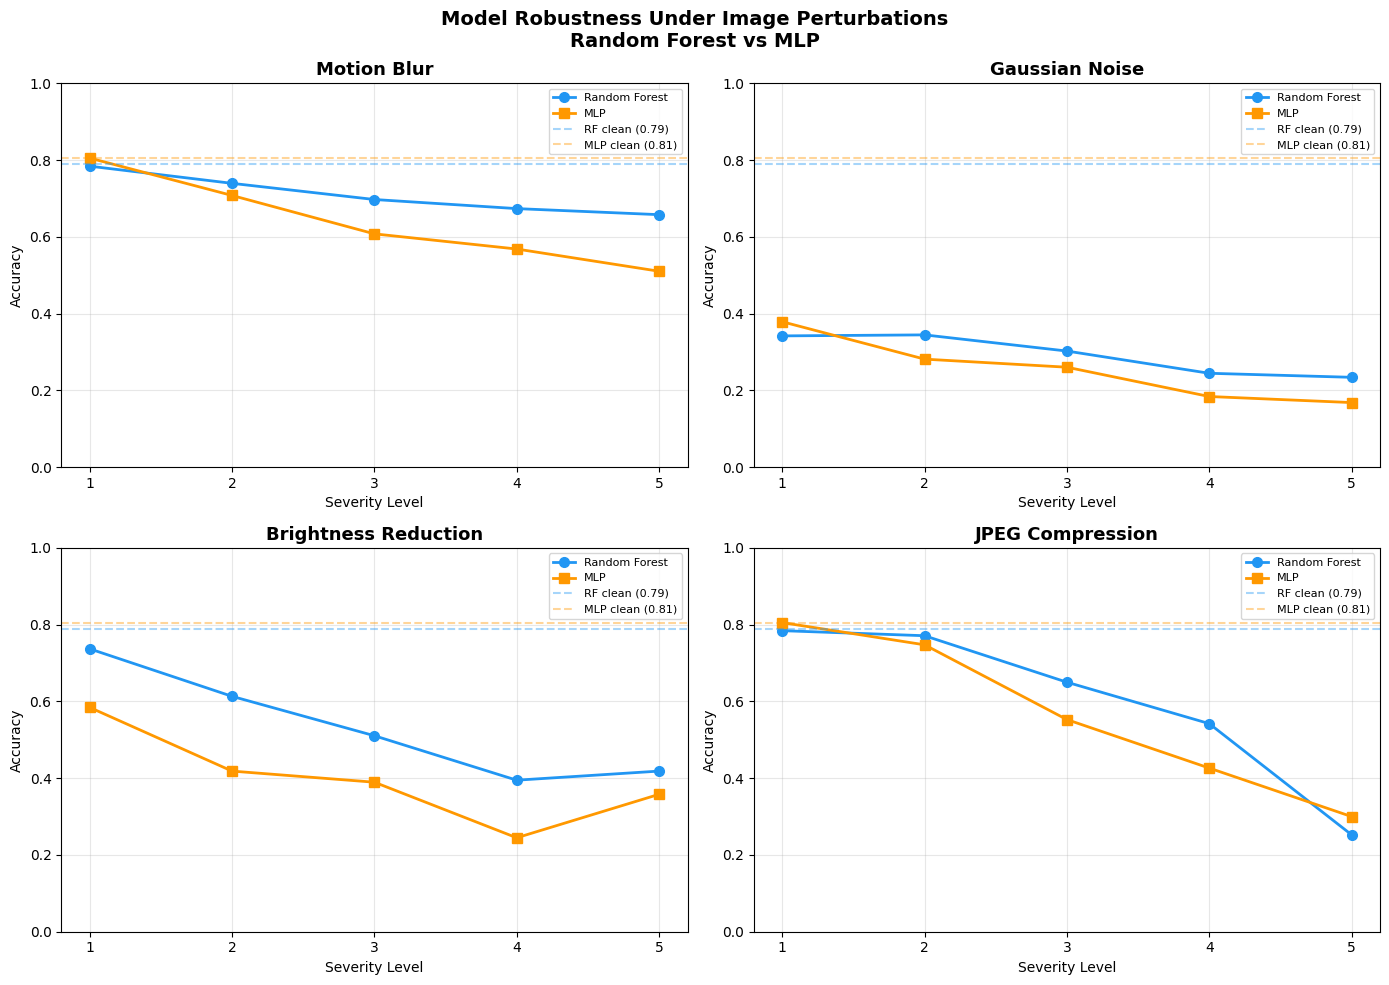

Robustness curves saved.


In [10]:
# Plots accuracy-vs-severity degradation curves for each perturbation type, comparing RF and MLP side by side

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

perturbation_titles = {
    'motion_blur':      'Motion Blur',
    'gaussian_noise':   'Gaussian Noise',
    'brightness':       'Brightness Reduction',
    'jpeg_compression': 'JPEG Compression'
}

for idx, (perturb_name, title) in enumerate(perturbation_titles.items()):
    ax = axes[idx]
    
    rf_accs  = [robustness_results[perturb_name][s][0] for s in SEVERITIES]
    mlp_accs = [robustness_results[perturb_name][s][1] for s in SEVERITIES]
    
    ax.plot(SEVERITIES, rf_accs,  'o-', color='#2196F3', linewidth=2,
            markersize=7, label='Random Forest')
    ax.plot(SEVERITIES, mlp_accs, 's-', color='#FF9800', linewidth=2,
            markersize=7, label='MLP')
    
    ax.axhline(y=rf_clean_acc,  color='#2196F3', linestyle='--',
               alpha=0.4, label=f'RF clean ({rf_clean_acc:.2f})')
    ax.axhline(y=mlp_clean_acc, color='#FF9800', linestyle='--',
               alpha=0.4, label=f'MLP clean ({mlp_clean_acc:.2f})')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Severity Level')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(SEVERITIES)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Robustness Under Image Perturbations\nRandom Forest vs MLP',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'robustness_curves.png'), dpi=150)
plt.show()
print("Robustness curves saved.")

In [11]:
summary = {
    'clean_baseline': {
        'rf':  rf_clean_acc,
        'mlp': mlp_clean_acc
    },
    'robustness_results': results_serialisable
}

with open(os.path.join(RESULTS_PATH, 'robustness_results.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nClean baseline:")
print(f"  RF  : {rf_clean_acc:.4f}")
print(f"  MLP : {mlp_clean_acc:.4f}")

print(f"\nAccuracy at severity 5 (worst case):")
for perturb_name in PERTURBATIONS:
    rf_s5  = robustness_results[perturb_name][5][0]
    mlp_s5 = robustness_results[perturb_name][5][1]
    winner = 'RF' if rf_s5 >= mlp_s5 else 'MLP'
    print(f"  {perturb_name:20} RF: {rf_s5:.3f} | MLP: {mlp_s5:.3f} | Winner: {winner}")


Clean baseline:
  RF  : 0.7895
  MLP : 0.8053

Accuracy at severity 5 (worst case):
  motion_blur          RF: 0.658 | MLP: 0.511 | Winner: RF
  gaussian_noise       RF: 0.234 | MLP: 0.168 | Winner: RF
  brightness           RF: 0.418 | MLP: 0.358 | Winner: RF
  jpeg_compression     RF: 0.253 | MLP: 0.300 | Winner: MLP
